we are gonna use suppervised regression model (predicting a numeric data)

XGBoost regressor is used

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import svm
from xgboost import XGBRegressor #regression model
import seaborn as sns # for heatmap to get correlation comparision esily btw all features
import matplotlib.pyplot as plt #for visualization
from sklearn import metrics #for seeing the accuracy by calculating errors (not like classification models)
import sklearn.datasets


In [ ]:
house_price_dataset = pd.read_csv('/content/BostonHousing.csv')

In [ ]:
house_price_dataset.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
house_price_dataset.shape

(506, 14)

In [ ]:
house_price_dataset.isnull().sum() #checking nulls

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,5
age,0
dis,0
rad,0
tax,0


In [ ]:
house_price_dataset.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,3.647414,11.402196,11.160619,0.069860,0.555151,6.284341,68.513373,3.786423,9.596806,409.143713,18.453493,356.298523,12.643752,22.561277
std,8.637688,23.414214,6.857123,0.255166,0.116186,0.705587,28.212221,2.103327,8.735509,169.021216,2.166327,91.672055,7.162746,9.232435
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081990,0.000000,5.190000,0.000000,0.449000,5.884000,45.000000,2.088200,4.000000,279.000000,17.400000,375.210000,6.920000,17.000000
50%,0.261690,0.000000,9.690000,0.000000,0.538000,6.208000,77.700000,3.182700,5.000000,330.000000,19.000000,391.340000,11.380000,21.200000
75%,3.693110,12.500000,18.100000,0.000000,0.624000,6.625000,94.000000,5.118000,24.000000,666.000000,20.200000,396.230000,16.940000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
house_price_dataset.dropna(inplace=True) #dropping the null row using dropna inplace true it itself modifies
#the dataset and return none but if we dont use the inplace true its default is false and it drops but returns
# a data set wh have to be stored again

In [ ]:
house_price_dataset.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [ ]:
correlation=house_price_dataset.corr()

<Axes: >

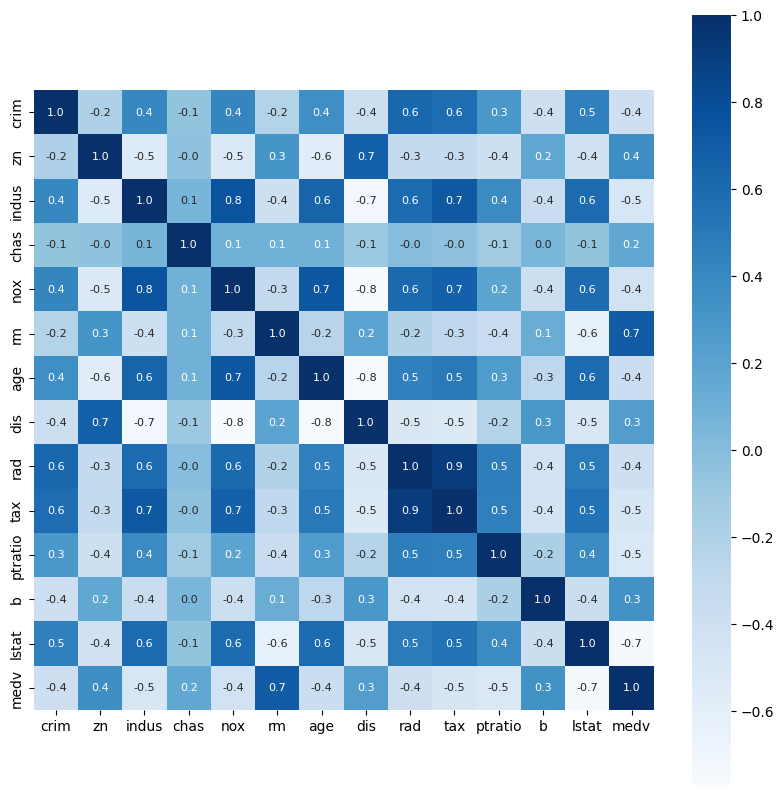

In [ ]:
#constructing heatmap to understanding correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')
#cbar=colourbars
#square all in squares
#fmt 1 value after decimal
#annot mention with size

splitting data

In [ ]:
X=house_price_dataset.drop(['medv'],axis=1)
Y=house_price_dataset['medv']


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
X.shape,X_train.shape,X_test.shape

((501, 13), (400, 13), (101, 13))

Model training XGBoost Regressor
#its a decision tree model

In [ ]:
model=XGBRegressor() #loading the machine

In [ ]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

# evaluating the model (we cant use accuracy scorer )we use metrics

In [ ]:
#lets do the prediction
training_prediction=model.predict(X_train)

In [ ]:
#lets now find accuracy
#using R squared error and mean absolute error
score_1=metrics.r2_score(Y_train,training_prediction)
 #r2 compares variances btw ytrain and predicted values
score_2=metrics.mean_absolute_error(Y_train,training_prediction)

print("R squared error: ",score_1)
print("Mean absolute error: ",score_2)


R squared error:  0.999998365060351
Mean absolute error:  0.008044352054595947


testing

In [ ]:
prediction_test=model.predict(X_test)

In [ ]:
s_1=metrics.r2_score(Y_test,prediction_test)
s_2=metrics.mean_absolute_error(Y_test,prediction_test)

print("R squared error: ",s_1)
print("Mean absolute error: ",s_2)

R squared error:  0.8782098280047841
Mean absolute error:  2.1109944050854974


#visualizing the predictions and actualusing scattered plot

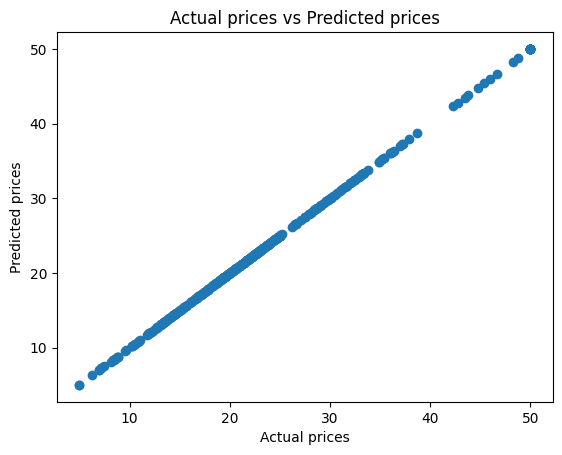

In [ ]:
plt.scatter(Y_train,training_prediction)
plt.xlabel("Actual prices")
plt.ylabel("Predicted pries")
plt.title("Actual prices vs Predicted prices")
plt.show()

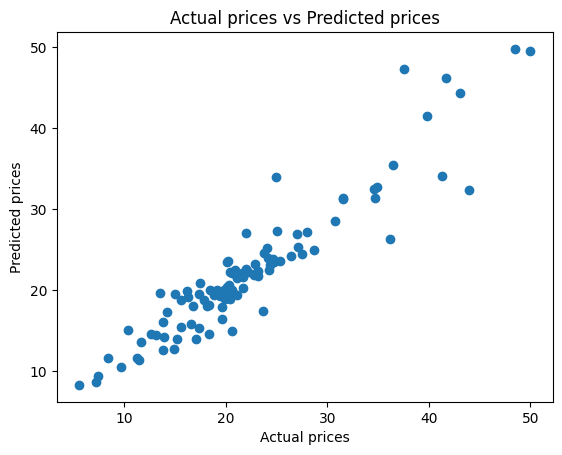

In [ ]:
plt.scatter(Y_test,prediction_test)
plt.xlabel("Actual prices")
plt.ylabel("Predicted prices")
plt.title("Actual prices vs Predicted prices")
plt.show()